In [2]:
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from captum.attr import IntegratedGradients, LRP

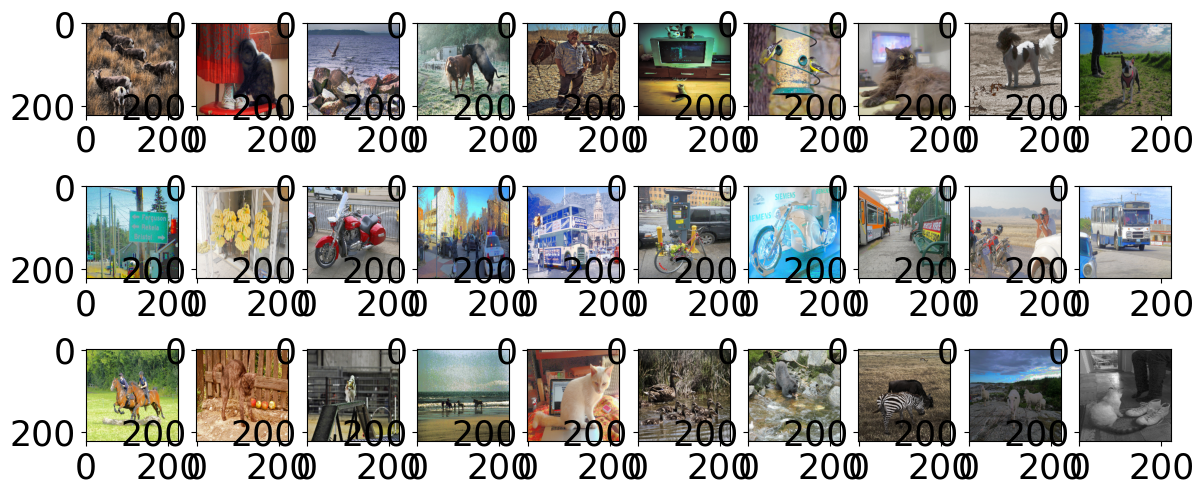

In [245]:
split = 0

with open(f'./artifacts/split_{split}_coco_data_norm_test.pkl', 'rb') as f:
    [x_test_norm, y_test_norm, masks_test_norm, _, _] = pkl.load(f)

norm_loader = DataLoader(TensorDataset(torch.tensor(x_test_norm.transpose(0,3,1,2)), torch.tensor(y_test_norm)), batch_size=batch_size, shuffle=False, num_workers=4)

with open(f'./artifacts/split_{split}_coco_data_dark_test.pkl', 'rb') as f:
    [x_test_dark, y_test_dark, masks_test_dark, _, _] = pkl.load(f)

dark_loader = DataLoader(TensorDataset(torch.tensor(x_test_dark.transpose(0,3,1,2)), torch.tensor(y_test_dark)), batch_size=batch_size, shuffle=False, num_workers=4)

with open(f'./artifacts/split_{split}_coco_data_light_test.pkl', 'rb') as f:
    [x_test_light, y_test_light, masks_test_light, _, _] = pkl.load(f)

light_loader = DataLoader(TensorDataset(torch.tensor(x_test_light.transpose(0,3,1,2)), torch.tensor(y_test_light)), batch_size=batch_size, shuffle=False, num_workers=4)

### Checking that the manips strings have tracked the manipulations correctly
fig, axs = plt.subplots(3,10, figsize=(14,6))

for i, manip in enumerate(['norm', 'light', 'dark']):
    inds = np.where(np.array(manips_conf) == manip)[0][:10]
    for j in range(10):
        axs[i,j].imshow(cv2.cvtColor( (x_test_conf[inds[j]]*255).astype(np.uint8)  , cv2.COLOR_HLS2RGB ))


In [3]:
split = 0
with open(f'./artifacts/split_{split}_coco_data_norm_test.pkl', 'rb') as f:
    [x_test_norm, y_test_norm, masks_test_norm, manips] = pkl.load(f)

In [4]:
manips[:100]

array([476710., 341270., 421333., 338531., 173984., 560242.,  71281.,
       255886., 546298., 471521.,  89154., 477758., 358083., 208589.,
       293066.,  26504., 142779., 149230., 102118.,  44583., 477598.,
       532975., 367433., 286149., 254645., 510734., 268388.,  37871.,
       401138., 181413., 461129., 333509., 229658., 577455., 194203.,
       522930., 275325.,   2477., 152737., 366787.,  33900., 382714.,
       311578., 576714., 324500., 346560., 449701., 158806., 167193.,
       338732.,  20371., 321196., 429819., 207889., 438667.,  38440.,
       310058., 125898.,  92020., 515695., 535563.,   9830.,  22759.,
       391496., 249620., 200477., 220071., 530811., 382171., 336302.,
       200202., 428214., 337256., 499082., 239930., 516396., 215616.,
       370798., 206541., 209728., 420939., 219177., 540652., 432330.,
       104692.,  55363., 397309., 530731., 543210., 385379., 336075.,
       492710., 574074., 388020., 459566., 208201.,    772., 334616.,
       416006., 1399

In [50]:
a = [1,2,3,4,5]
b = []
print(b)
b.extend(a)
print(b)

[]
[1, 2, 3, 4, 5]


In [174]:

# def average abs attribution of particular HLS channel, divided by average absolute pixel attribution across the whole image
def channel_ratio(attr, channel):
    return np.mean(np.abs(attr[:,:,channel]))/np.mean(np.abs(attr))

In [175]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(in_channels=3,out_channels=64,kernel_size=5, padding='same')
        self.conv2=nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3, padding='same')
        self.conv3=nn.Conv2d(in_channels=128,out_channels=256,kernel_size=5, padding='same')
        
        self.maxPooling2=nn.MaxPool2d(kernel_size=2)
        self.maxPooling4_0=nn.MaxPool2d(kernel_size=4)
        self.maxPooling4_1=nn.MaxPool2d(kernel_size=4)
#         self.adPooling=nn.AdaptiveAvgPool1d(256)
        
        self.fc1=nn.Linear(in_features=12544,out_features=128)
        self.fc2=nn.Linear(in_features=128,out_features=64)
        self.out=nn.Linear(in_features=64,out_features=2)

    def forward(self,x):
        x=self.conv1(x)
        x=self.maxPooling4_0(x)
        x=F.relu(x)
        
        x=self.conv2(x)
        x=self.maxPooling4_1(x)
        x=F.relu(x)
        
        x=self.conv3(x)
        x=self.maxPooling2(x)
        x=F.relu(x)
        
        x=F.dropout(x)
        x=x.view(1,x.size()[0],-1) #stretch to 1d data
        #x=self.adPooling(x).squeeze()
        
        x=self.fc1(x)
        x=F.relu(x)
        
        x=self.fc2(x)
        x=F.relu(x)
        
        x=self.out(x)
        
        return x[0]

In [177]:
split = 0
batch_size = 32

# with open(f'./artifacts/split_{split}_coco_data_norm_test.pkl', 'rb') as f:
#     [x_test_norm, y_test_norm, masks_test_norm, _, _] = pkl.load(f)

# norm_loader = DataLoader(TensorDataset(torch.tensor(x_test_norm.transpose(0,3,1,2)), torch.tensor(y_test_norm)), batch_size=batch_size, shuffle=False, num_workers=4)

with open(f'./artifacts/split_{split}_coco_data_conf_test.pkl', 'rb') as f:
    [x_test_conf, y_test_conf, masks_test_conf, _, _] = pkl.load(f)

# with open(f'coco_data_conf.pkl', 'rb') as f:
#     [(_, _, _), (_, _, _), (x_test, y_test, masks_test_conf)] = pkl.load(f)

conf_loader = DataLoader(TensorDataset(torch.tensor(x_test_conf.transpose(0,3,1,2)), torch.tensor(y_test_conf)), batch_size=batch_size, shuffle=False, num_workers=4)

# with open(f'./artifacts/split_{split}_coco_data_sup_test.pkl', 'rb') as f:
#     [x_test_sup, y_test_sup, masks_test_sup, _, _] = pkl.load(f)

# sup_loader = DataLoader(TensorDataset(torch.tensor(x_test_sup.transpose(0,3,1,2)), torch.tensor(y_test_sup)), batch_size=batch_size, shuffle=False, num_workers=4)

In [178]:
def load_trained(path):
    model = Net()
    model.load_state_dict(torch.load(path), map_location=torch.device('cpu'), weights_only=True)
    return model

In [179]:
model_name = 'conf'
model_ind = 0
n_explain = 1

path = f'./models/coco_{model_name}_{split}_{model_ind}.pt'
model = Net()
model.load_state_dict(torch.load(path, map_location=torch.device('cpu'), weights_only=True))

<All keys matched successfully>

In [180]:
explanations = []
 
for x_batch, test_labels in conf_loader:      

    for j in range(n_explain):
                
        data = x_batch[j].reshape(1,3,224,224).to(torch.float32)
        target = torch.tensor(test_labels[j]).to(torch.int16)

        lrp_att=LRP(model).attribute(data,target=target).detach().numpy().squeeze()
        print(lrp_att.shape)

        for channel_ind in range(3):
                    # like above, only need to calculate x (data) energies once, as it is model independent
            if model_name == 'conf':
                explanations.append(channel_ratio(lrp_att, channel_ind))

    break

/tmp/ipykernel_641493/2959091358.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(test_labels[j]).to(torch.int16)
/home/clark01/mambaforge/envs/debugging/lib/python3.13/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(


(3, 224, 224)


In [181]:
lrp_att.shape

(3, 224, 224)

In [184]:
channel_ind=2
channel_ratio(np.transpose(lrp_att, (1,2,0)), channel_ind)

np.float32(1.2996362)

In [32]:
channel_ratio(lrp_att, 2)

np.float32(1.0733404)

In [34]:
print(lrp_att.shape, lrp_att.transpose(1,2,0).shape)

(3, 224, 224) (224, 224, 3)


In [33]:
channel_ratio(lrp_att.transpose(1,2,0), 2)

np.float32(1.2946923)

In [25]:
np.sum(np.abs(lrp_att))

np.float32(85.16194)

In [12]:
lrp_att = lrp_att.transpose(1,2,0)
lrp_att.shape

(224, 224, 3)

In [13]:
print(np.sum(np.abs(lrp_att[:,:,0])), np.sum(np.abs(lrp_att[:,:,1])), np.sum(np.abs(lrp_att[:,:,2])), np.sum(np.abs(lrp_att)))

9.701447 38.38032 37.080166 85.16194


In [27]:
np.mean(np.abs(lrp_att[:,:,1]))/np.mean(np.abs(lrp_att)) - np.mean(np.abs(lrp_att[:,:,0]))/np.mean(np.abs(lrp_att)) - np.mean(np.abs(lrp_att[:,:,2]))/np.mean(np.abs(lrp_att))

np.float32(-0.29595232)

In [18]:
channel_ratio(lrp_att, 0)

np.float32(0.3417529)

In [28]:
chann_sum = np.sum(np.abs(lrp_att[:,0]))

In [38]:
lrp_att.transpose(1,2,0).shape

(224, 224, 3)

In [40]:
lrp_att.transpose(1,2,0)[:,:,0].shape

(224, 224)

In [29]:
(np.sum(np.abs(lrp_att)) - np.sum(np.abs(lrp_att[:,0])))

np.float32(71.94286)

In [ ]:
/(np.sum(np.abs(attr)) - np.sum(np.abs(attr[:,channel])))

In [1]:
def get_energies(method, rgb=False):
    conf_conf = [[],[],[]]
    conf_sup = [[],[],[]]
    conf_no = [[],[],[]]
    
    sup_conf = [[],[],[]]
    sup_sup = [[],[],[]]
    sup_no = [[],[],[]]
    
    no_conf = [[],[],[]]
    no_sup = [[],[],[]]
    no_no = [[],[],[]]

    rgb_string=''
    if rgb:
        rgb_string = '_rgb'
    
    for split in range(5):
        for model_ind in range(5):
            with open(f'./energies/energies_coco_{split}_{model_ind}{rgb_string}.pickle', 'rb') as file:
                energies = pkl.load(file)
            
            for i in range(3):
                conf_conf[i].extend(energies['conf']['conf'][i][method])
                conf_sup[i].extend(energies['conf']['sup'][i][method])
                conf_no[i].extend(energies['conf']['norm'][i][method])
                
                sup_conf[i].extend(energies['sup']['conf'][i][method])
                sup_sup[i].extend(energies['sup']['sup'][i][method])
                sup_no[i].extend(energies['sup']['norm'][i][method])
        
                no_conf[i].extend(energies['norm']['conf'][i][method])
                no_sup[i].extend(energies['norm']['sup'][i][method])
                no_no[i].extend(energies['norm']['norm'][i][method])
                
    
        with open(f'./energies/energies_coco_x{rgb_string}_{split}.pickle', 'rb') as file:
                energies_x = pkl.load(file)
        
        combined_energies = {
            'conf': { # conf model on conf/sup/no data
                'conf': conf_conf,
                'sup': conf_sup, 
                'norm': conf_no},
                    
            'sup': { # sup model on conf/sup/no data
                'conf': sup_conf,
                'sup': sup_sup, 
                'norm': sup_no},
        
            'norm': { # no_col model on conf/sup/no data
                'conf': no_conf,
                'sup': no_sup, 
                'norm': no_no},
            
            'x': { # "energy" (proportion of total mass) of the data itself
                'conf': energies_x[0],
                'sup': energies_x[1],
                'norm': energies_x[2]
            }
        }

    return combined_energies

In [66]:
# 3 channel HLS energy plotting
def plot_energies(combined_energies, method, rgb=False, show=False):
    font_size = 16
    
    fig,axs=plt.subplots(4,3, figsize=(15,10))
    # sns.histplot(ax=axs[1,1],data=[energies['conf']['conf'][0]['lrp_ab'], energies['conf']['conf'][1]['lrp_ab'], energies['conf']['conf'][2]['lrp_ab']],bins=100)
    
    for i, model_name in enumerate(['conf', 'sup', 'norm', 'x']):
        
        for j, dataset in enumerate(['conf', 'sup', 'norm']):
            if i == 0:
                axs[0,j].set_title(dataset, fontsize=font_size)
    #         sns.histplot(ax=axs[i,j],data=[combined_energies[model_name][dataset][0], combined_energies[model_name][dataset][1], combined_energies[model_name][dataset][2]],bins=1000, color=['red','green','blue'])
            
            sns.histplot(ax=axs[i,j],data=combined_energies[model_name][dataset][0],bins=100, color='orange', edgecolor='black')
            sns.histplot(ax=axs[i,j],data=combined_energies[model_name][dataset][1],bins=100, color='green', edgecolor='black', alpha=0.6)
            sns.histplot(ax=axs[i,j],data=combined_energies[model_name][dataset][2],bins=100, edgecolor='black')
        
            # sns.histplot(ax=axs[i,j],data=[np.sum([combined_energies[model_name][dataset][0], combined_energies[model_name][dataset][2]],axis=0), combined_energies[model_name][dataset][0]],bins=100, color=['red','green','blue'])
    #         plt.xlim(0.4,0.58)
            # axs[i,j].set_xlim([0.0, 1.0])
            # axs[i,j].set_ylim([0, 200])
            axs[i, j].legend([],[], frameon=False)
    #         axs[i,j].set_ylabel('')
            
    #         if i!=2:
    #             axs[i,j].set_xticks([])
                
    #         if j!=0:
    #             axs[i,j].set_yticks([])
            
            #         axs[i,j].set_title(f'model: {model_name}, dataset: {dataset}')       
        
        axs[i,0].set_ylabel(model_name, fontsize=16)
    
    # axs[0,0].legend(['red channel', 'sum(green,blue)'],loc='upper center', bbox_to_anchor=(3.0, 1.5), ncol=1)
    # axs[0,0].legend(['red channel', 'blue channel'],loc='upper center', bbox_to_anchor=(3.0, 1.5), ncol=1)

    if not rgb:
        axs[0,0].legend(['hue channel', 'lightness channel', 'saturation channel'],loc='upper center', bbox_to_anchor=(3.0, 1.5), ncol=1)
    else:
        axs[0,0].legend(['red channel', 'green channel', 'blue channel'],loc='upper center', bbox_to_anchor=(3.0, 1.5), ncol=1)
    
    plt.figtext(0.07,0.5,"Model", va="center", ha="center", size=font_size+2,rotation='vertical')
    plt.figtext(0.5,0.95,"Test Dataset", va="center", ha="center", size=font_size+2,)

    method_label = method
    if method == 'lrp_ab':
        method_label = r'LRP-$\alpha$$\beta$'
    elif method == 'lrp':
        method_label = r'LRP-$\epsilon$'
    
    plt.figtext(0.5,0.05,f"Proportion of importance per channel ({method_label})", va="center", ha="center", size=font_size+2,)

    rgb_string=''
    if rgb:
        rgb_string = '_rgb'
    
    plt.savefig(f'./figures/coco/quantitative_{method}{rgb_string}.png', bbox_inches='tight')
    plt.savefig(f'./figures/coco/quantitative_{method}{rgb_string}_hires.png', bbox_inches='tight', dpi=300)

    if show:
        plt.show()

In [67]:
# H and S channels combined for sum(H,S) vs (L) comparison
def plot_combined(combined_energies, method, show=False):
    font_size = 16
    
    fig,axs=plt.subplots(4,3, figsize=(15,10))
    # sns.histplot(ax=axs[1,1],data=[energies['conf']['conf'][0]['lrp_ab'], energies['conf']['conf'][1]['lrp_ab'], energies['conf']['conf'][2]['lrp_ab']],bins=100)
    
    for i, model_name in enumerate(['conf', 'sup', 'norm', 'x']):
        
        for j, dataset in enumerate(['conf', 'sup', 'norm']):
            if i == 0:
                axs[0,j].set_title(dataset, fontsize=font_size)
    #         sns.histplot(ax=axs[i,j],data=[combined_energies[model_name][dataset][0], combined_energies[model_name][dataset][1], combined_energies[model_name][dataset][2]],bins=1000, color=['red','green','blue'])
            
            # sns.histplot(ax=axs[i,j],data=combined_energies[model_name][dataset][0],bins=100, color='orange', edgecolor='black')
            # sns.histplot(ax=axs[i,j],data=combined_energies[model_name][dataset][1],bins=100, color='green', edgecolor='black', alpha=0.6)
            # sns.histplot(ax=axs[i,j],data=combined_energies[model_name][dataset][2],bins=100, edgecolor='black')
        
            sns.histplot(ax=axs[i,j],data=[np.sum([combined_energies[model_name][dataset][0], combined_energies[model_name][dataset][2]],axis=0), combined_energies[model_name][dataset][1]],bins=100)
    #         plt.xlim(0.4,0.58)
            # axs[i,j].set_xlim([0.0, 1.0])
            # axs[i,j].set_ylim([0, 200])
            axs[i, j].legend([],[], frameon=False)
    #         axs[i,j].set_ylabel('')
            
    #         if i!=2:
    #             axs[i,j].set_xticks([])
                
    #         if j!=0:
    #             axs[i,j].set_yticks([])
            
            #         axs[i,j].set_title(f'model: {model_name}, dataset: {dataset}')

        
        axs[i,0].set_ylabel(model_name, fontsize=16)

    axs[0,0].legend(['lightness', 'sum(hue,saturation)'],loc='upper center', bbox_to_anchor=(3.0, 1.5), ncol=1)
    
    # axs[0,0].legend(['hue channel', 'lightness channel', 'saturation channel'],loc='upper center', bbox_to_anchor=(3.0, 1.5), ncol=1)
    method_label = method
    if method == 'lrp_ab':
        method_label = r'LRP-$\alpha$$\beta$'
    elif method == 'lrp':
        method_label = r'LRP-$\epsilon$'
            

    
    plt.figtext(0.07,0.5,"Model", va="center", ha="center", size=font_size+2,rotation='vertical')
    plt.figtext(0.5,0.95,"Test Dataset", va="center", ha="center", size=font_size+2,)
    plt.figtext(0.5,0.05,f"Proportion of importance per channel ({method_label})", va="center", ha="center", size=font_size+2,)
    
    plt.savefig(f'./figures/coco/quantitative_{method}_combined.png', bbox_inches='tight')
    plt.savefig(f'./figures/coco/quantitative_{method}_combined_hires.png', bbox_inches='tight', dpi=300)

    if show:
        plt.show()

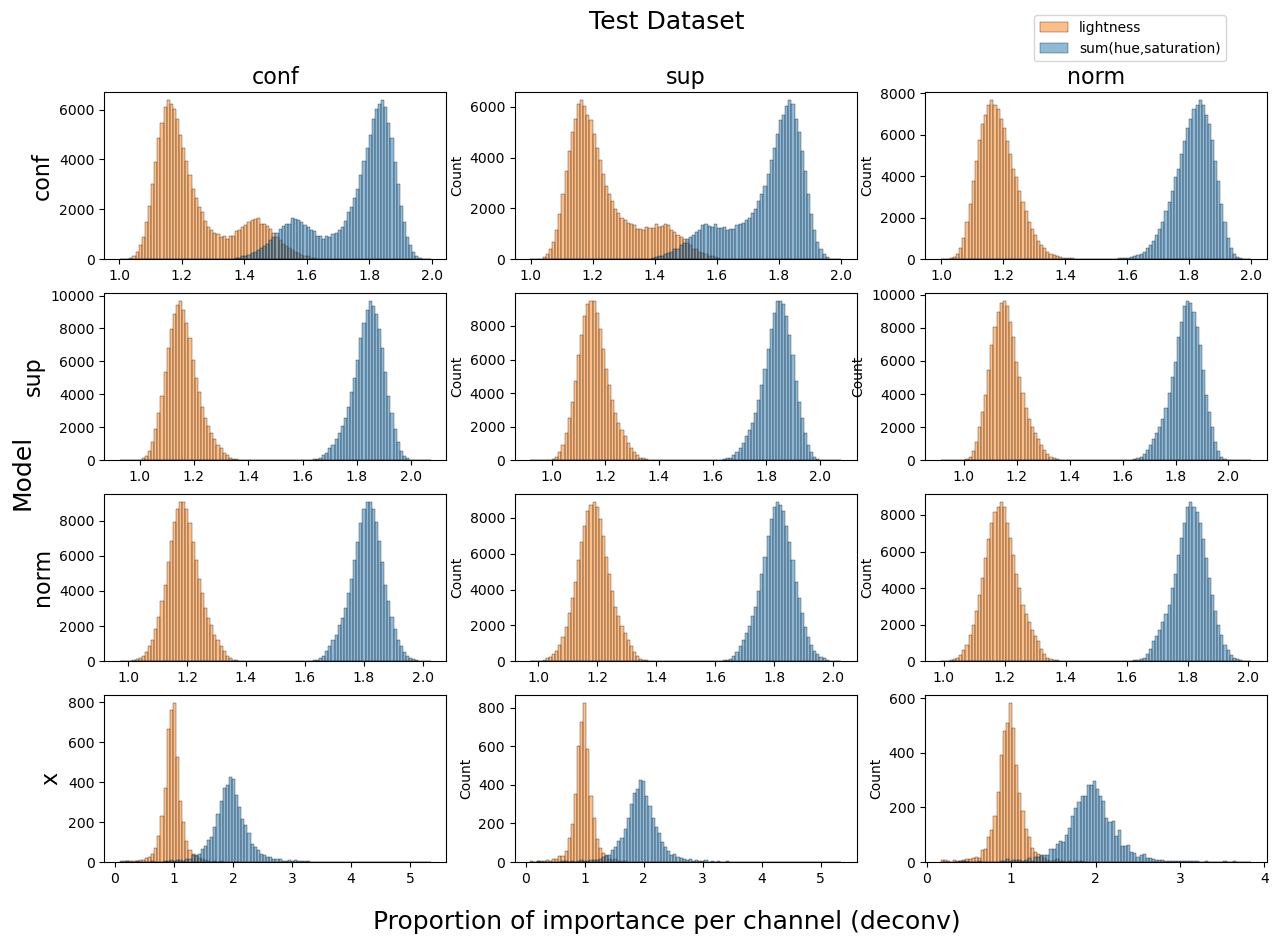

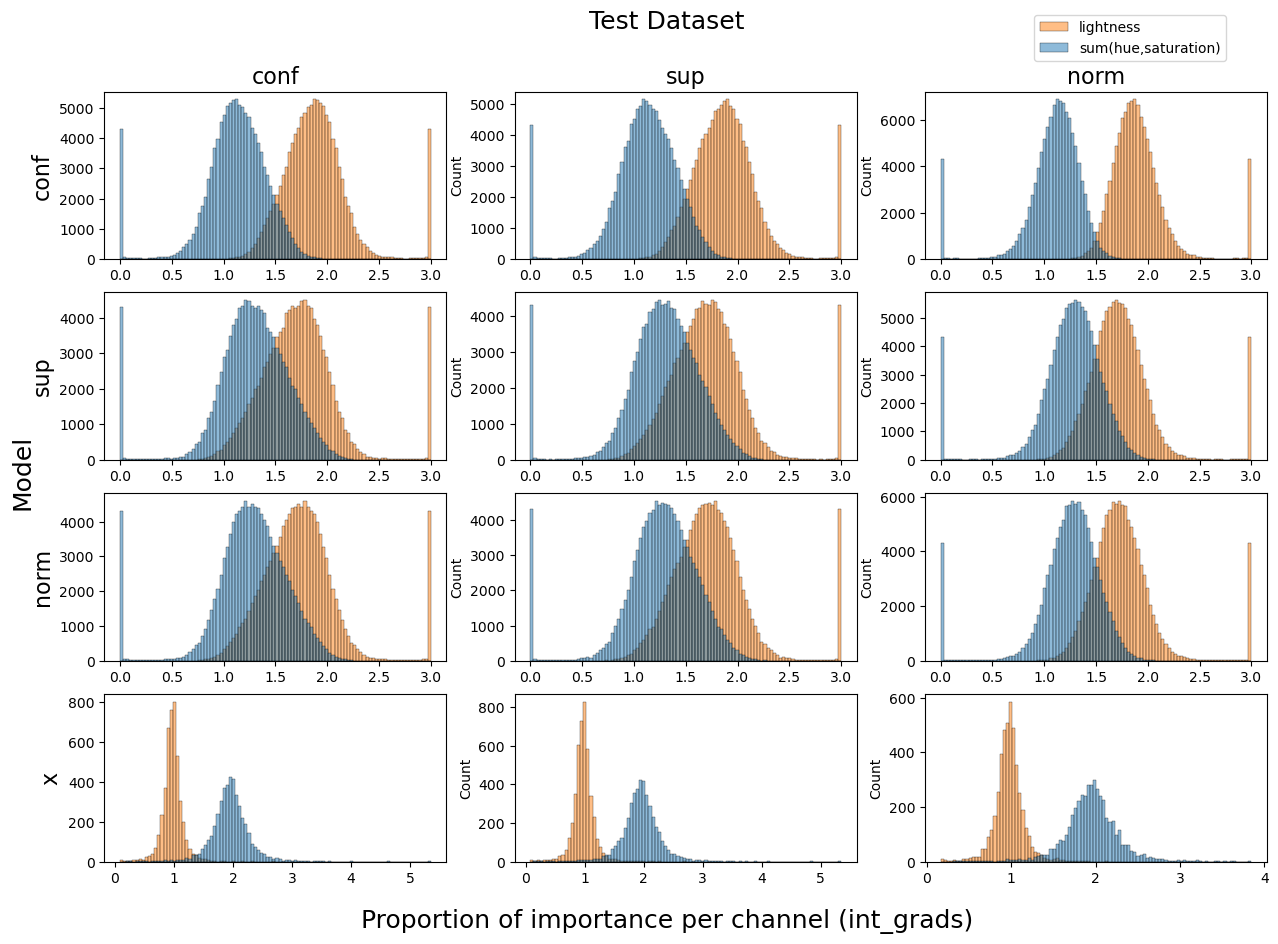

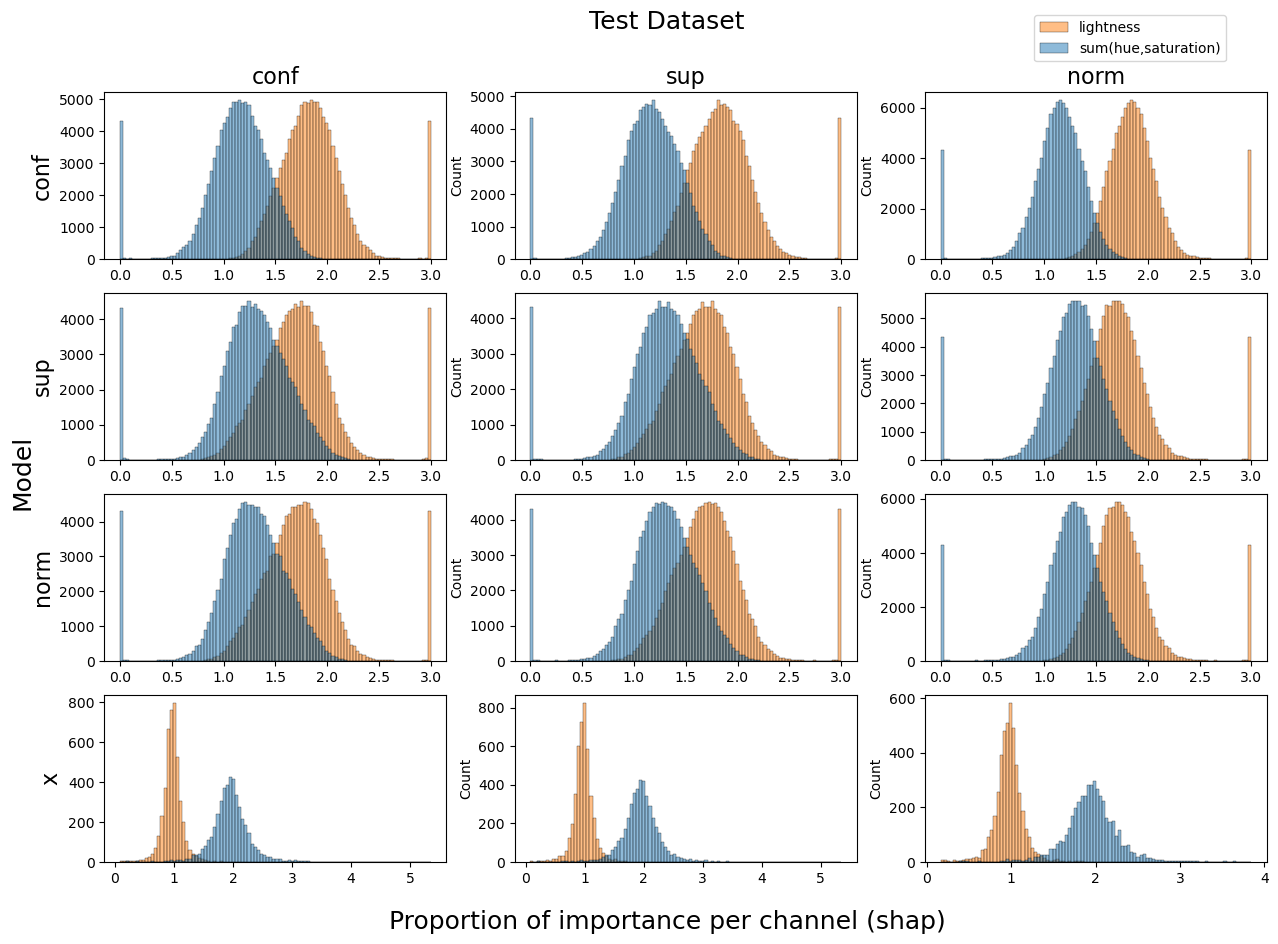

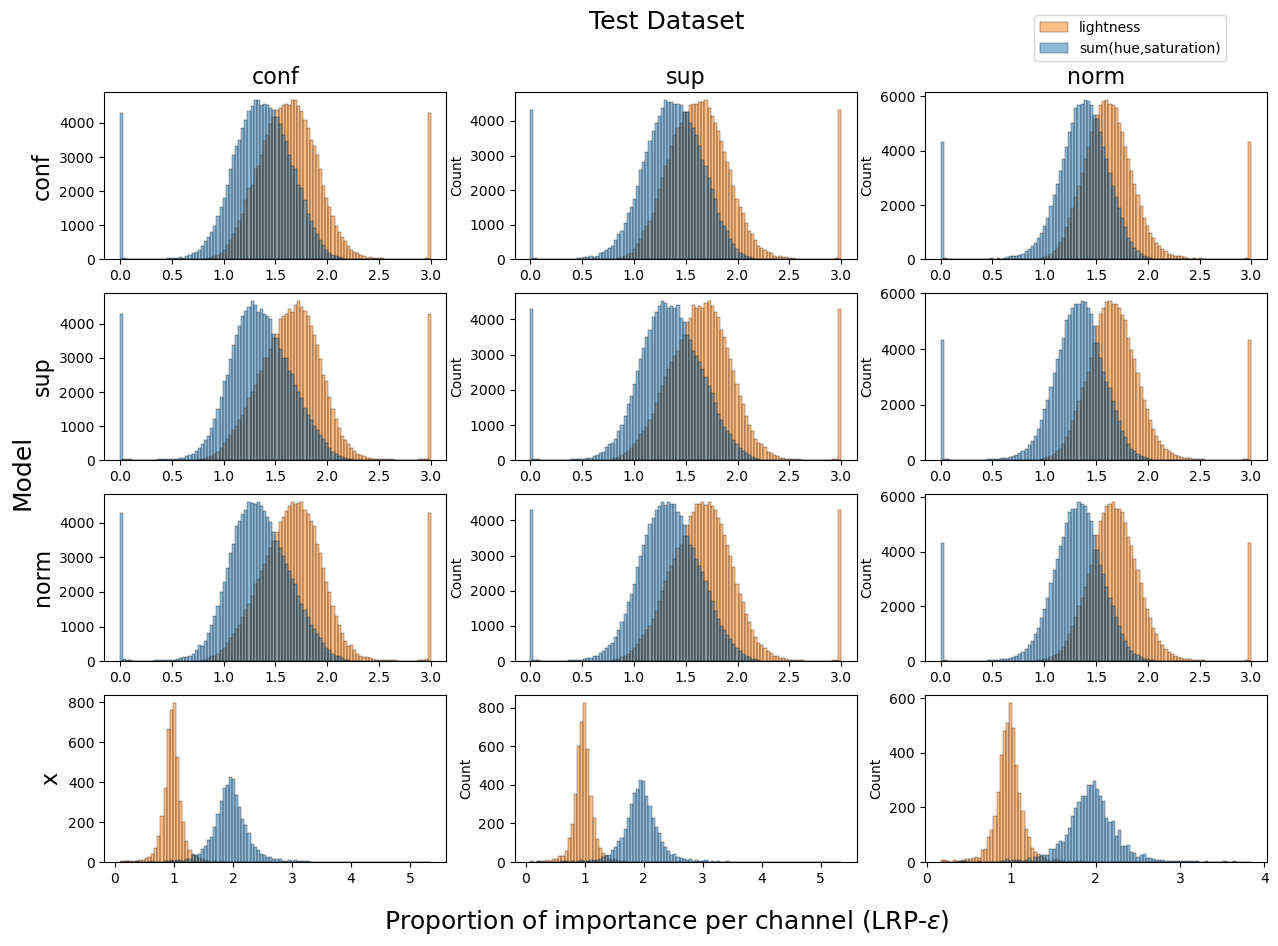

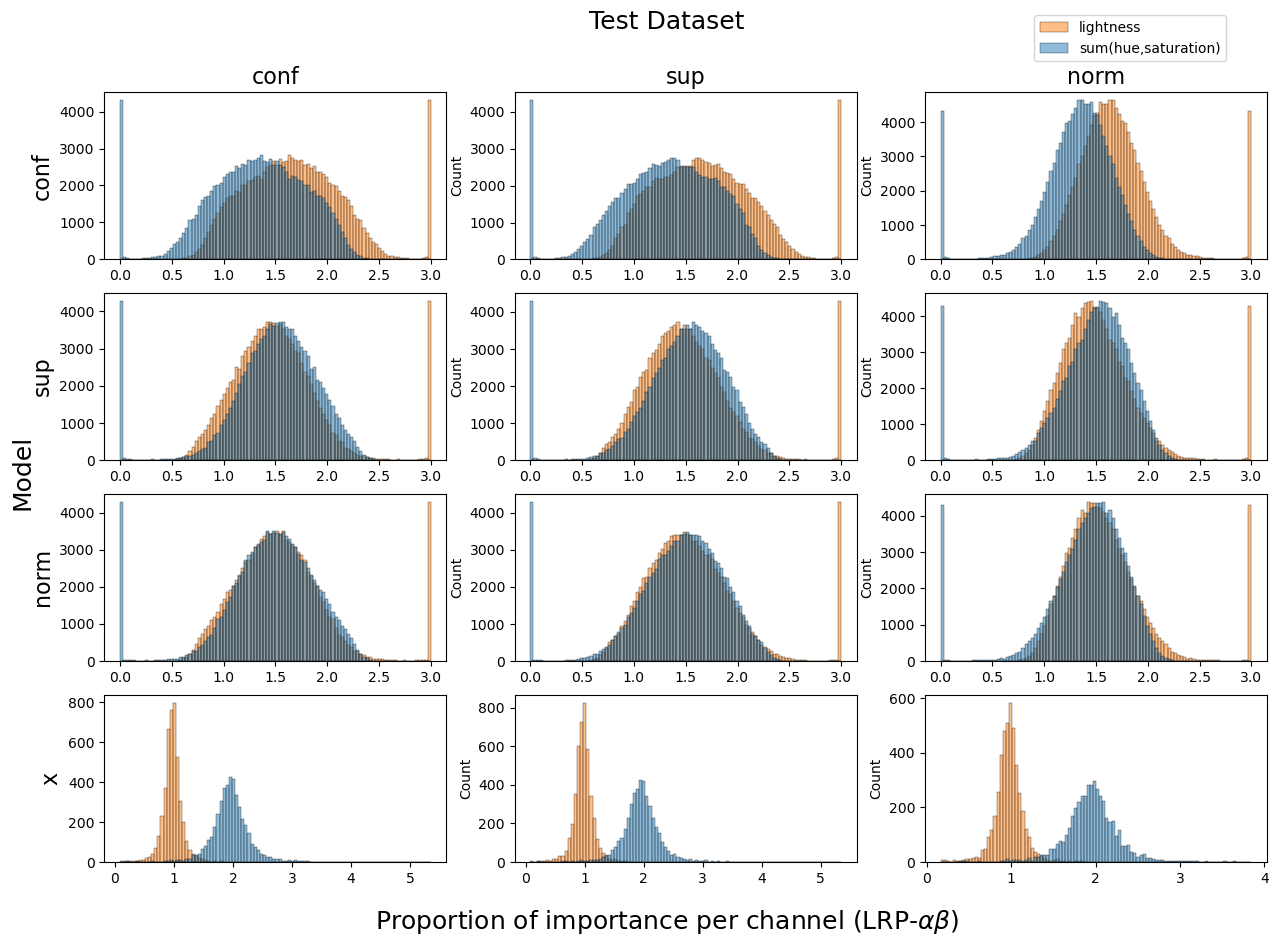

In [69]:
for method in ['deconv', 'int_grads', 'shap', 'lrp', 'lrp_ab']:
    combined_energies = get_energies(method)
    # plot_energies(combined_energies, method, rgb=False)
    plot_combined(combined_energies, method)

## L_norm vs L_bright / L_dark plots

In [79]:
import cv2

In [70]:
with open(f'./artifacts/split_0_coco_data_conf_test.pkl', 'rb') as f:
    [x_test_conf, y_test_conf, masks_test_conf, _, manips_conf] = pkl.load(f)

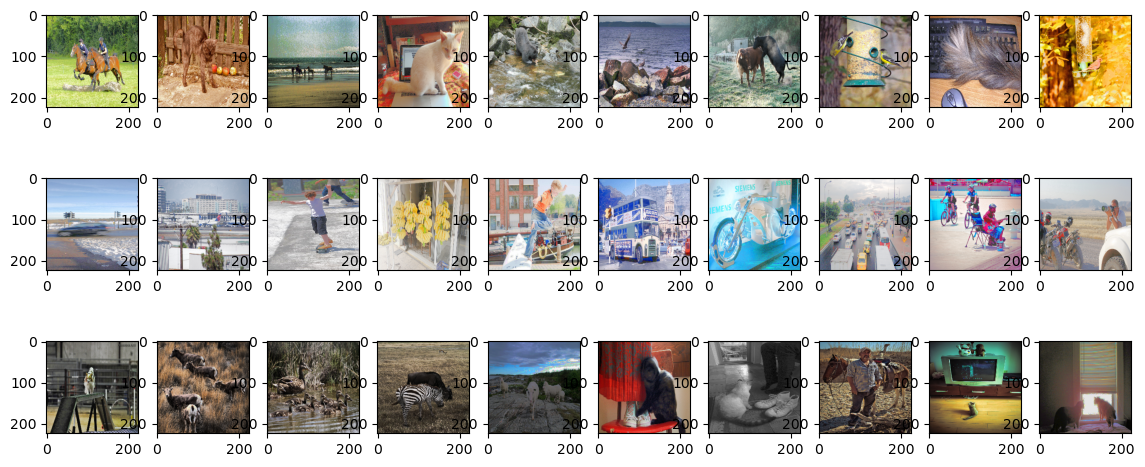

In [82]:
### Checking that the manips strings have tracked the manipulations correctly
fig, axs = plt.subplots(3,10, figsize=(14,6))

for i, manip in enumerate(['norm', 'light', 'dark']):
    inds = np.where(np.array(manips_conf) == manip)[0][:10]
    for j in range(10):
        axs[i,j].imshow(cv2.cvtColor( (x_test_conf[inds[j]]*255).astype(np.uint8)  , cv2.COLOR_HLS2RGB ))

In [99]:
split = 0
model_ind = 0 
rgb_string = ''
dataset = 'conf'

with open(f'./artifacts/split_{split}_coco_data_{dataset}_test.pkl', 'rb') as f:
    [_, _, _, _, manips_conf] = pkl.load(f)


with open(f'./energies/energies_coco_{split}_{model_ind}{rgb_string}.pickle', 'rb') as file:
    energies = pkl.load(file)

In [107]:
np.where(np.array(manips_conf) == 'norm')[0]

array([   0,    1,    4, ..., 4491, 4495, 4498], shape=(2215,))

In [109]:
len(np.array(energies['conf']['conf'][1]['deconv'])[np.where(np.array(manips_conf) == 'norm')[0]])

2215

In [112]:
len(np.array(energies['conf']['conf'][1]['deconv'])[np.where(np.array(manips_conf) == 'light')[0]])

1147

In [113]:
len(np.array(energies['conf']['conf'][1]['deconv'])[np.where(np.array(manips_conf) == 'dark')[0]])

1138

In [124]:
np.hstack([energies['conf']['conf'][1]['deconv'], energies['conf']['conf'][1]['deconv']]).shape

(9000,)

In [157]:
energies['conf']['conf'][1].keys()

dict_keys(['deconv', 'int_grads', 'shap', 'lrp', 'lrp_ab'])

In [222]:
with open(f'./energies/energies_coco_{split}_{model_ind}{rgb_string}.pickle', 'rb') as file:
    energies = pkl.load(file)

In [229]:
print("models   ", energies.keys())
print("datasets ", energies['norm'].keys())
print("channels ", len(energies['norm']['dark']))
print("methods  ", energies['norm']['dark'][1].keys())

models    dict_keys(['norm', 'conf', 'sup'])
datasets  dict_keys(['norm', 'dark', 'light'])
channels  3
methods   dict_keys(['deconv', 'int_grads', 'shap', 'lrp', 'lrp_ab'])


In [233]:
conf_animals

array([   0,    1,    2, ..., 2247, 2248, 2249], shape=(2250,))

In [29]:
# Get energies for a models (rows) vs methods (col) on in-distribution test data plot
import matplotlib.pyplot as plt
import pickle as pkl
import numpy as np
import seaborn as sns

def get_coco_energies(rescaled=False):
    rescaled_string = ''
    if rescaled:
        rescaled_string = '_rescaled'
        
    # each element should be a method 
    conf_animals = []
    conf_vehicles = []
    sup = []
    norm = []
    rgb_string = ''
    
    for split in range(5):
        with open(f'./artifacts/split_{split}_coco_data_norm_test{rescaled_string}.pkl', 'rb') as f:
            [_, labels_norm, _, _, _] = pkl.load(f)
    
        with open(f'./artifacts/split_{split}_coco_data_dark_test{rescaled_string}.pkl', 'rb') as f:
            [_, labels_dark, _, _, _] = pkl.load(f)
        
        with open(f'./artifacts/split_{split}_coco_data_light_test{rescaled_string}.pkl', 'rb') as f:
            [_, labels_light, _, _, _] = pkl.load(f)
    
        if len(labels_dark == labels_light) != len(labels_light) or len(labels_dark == labels_norm) != len(labels_norm) or len(labels_light == labels_norm) != len(labels_norm):
            print("LABELS NOT THE SAME. Test datasets should be the exact same so something serious has gone wrong.")
            break
    
        # conf_norm = np.where(np.array(manips_conf) == 'norm')[0]
        # conf_dark = np.where(np.array(manips_conf) == 'dark')[0]
        # conf_light = np.where(np.array(manips_conf) == 'light')[0]
    
        # sup_norm = np.where(np.array(manips_sup) == 'norm')[0]
        # sup_dark = np.where(np.array(manips_sup) == 'dark')[0]
        # sup_light = np.where(np.array(manips_sup) == 'light')[0]
    
        labels_animals = np.where(np.array(labels_norm) == 0)[0]
        labels_vehicles = np.where(np.array(labels_norm) == 1)[0]
    
        for model_ind in range(5):
            with open(f'./energies/energies_coco_{split}_{model_ind}{rgb_string}.pickle', 'rb') as file:
                energies = pkl.load(file)
    
            
            for i, method in enumerate(energies['conf']['norm'][1].keys()):
                if len(conf_animals) < (i+1):
                    conf_animals.append([[],[],[]])
                    conf_vehicles.append([[],[],[]])
                    sup.append([[],[],[]])
                    norm.append([[],[],[]])
                    # conf.append([conf_results[conf_norm], conf_results[conf_dark],  conf_results[conf_light]])
                    # sup.append([sup_results[sup_norm], sup_results[sup_dark],  sup_results[sup_light]])
                    # norm.append(np.array(energies['norm']['norm'][1][method]))
    
                conf_animals[i][0].extend(np.array(energies['conf']['norm'][1][method])[labels_animals])
                conf_vehicles[i][0].extend(np.array(energies['conf']['norm'][1][method])[labels_vehicles])
    
                conf_animals[i][1].extend(np.array(energies['conf']['dark'][1][method])[labels_animals])
                conf_vehicles[i][1].extend(np.array(energies['conf']['dark'][1][method])[labels_vehicles])
    
                conf_animals[i][2].extend(np.array(energies['conf']['light'][1][method])[labels_animals])
                conf_vehicles[i][2].extend(np.array(energies['conf']['light'][1][method])[labels_vehicles])
                
                sup[i][0].extend(np.array(energies['sup']['norm'][1][method]))
                sup[i][1].extend(np.array(energies['sup']['dark'][1][method]))
                sup[i][2].extend(np.array(energies['sup']['light'][1][method]))
    
                norm[i][0].extend(np.array(energies['norm']['norm'][1][method]))
                norm[i][1].extend(np.array(energies['norm']['dark'][1][method]))
                norm[i][2].extend(np.array(energies['norm']['light'][1][method]))
            
    return conf_animals, conf_vehicles, sup, norm

In [27]:
def channel_ratio(attr, channel):
    return np.mean(np.abs(attr[:,:,channel]))/np.mean(np.abs(attr))

def get_coco_xs(rescaled=False):
    rescaled_string = ''
    if rescaled:
        rescaled_string = '_rescaled'
        
    # each element should be a method 
    norm = []
    dark = []
    light = []
    
    for split in range(1):
        with open(f'./artifacts/split_{split}_coco_data_norm_test{rescaled_string}.pkl', 'rb') as f:
            [data_norm, _, _, _, _] = pkl.load(f)
    
        with open(f'./artifacts/split_{split}_coco_data_dark_test{rescaled_string}.pkl', 'rb') as f:
            [data_dark, _, _, _, _] = pkl.load(f)
        
        with open(f'./artifacts/split_{split}_coco_data_light_test{rescaled_string}.pkl', 'rb') as f:
            [data_light, _, _, _, _] = pkl.load(f)


        for i in range(data_norm.shape[0]):
            norm.append(channel_ratio(data_norm[i],1)) 
            dark.append(channel_ratio(data_dark[i],1)) 
            light.append(channel_ratio(data_light[i],1)) 
    return norm, dark, light

In [84]:
def remove_grayscales(arr):
    greyscale_inds = np.where(np.asarray(arr) > 2.9)[0]
    return [x for i,x in enumerate(arr) if i not in greyscale_inds]

In [100]:
def plot_coco_energies(conf_animals, conf_vehicles, sup, norm, x_norm, x_dark, x_light, rescaled=False):
    rescaled_string = ''
    if rescaled:
        rescaled_string = '_rescaled'
    fig, axs = plt.subplots(4, len(conf_animals)+1, figsize=(36, 15))
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    font_size=25
    plt.rcParams['font.size'] = font_size
    plt.rc('axes', titlesize=font_size) #title
    
    for j in range(len(conf_animals)):
        c_a=sns.histplot(ax=axs[0, j],data=[remove_grayscales(conf_animals[j][0]), remove_grayscales(conf_animals[j][1]), remove_grayscales(conf_animals[j][2])],bins=100)
        c_v=sns.histplot(ax=axs[1, j],data=[remove_grayscales(conf_vehicles[j][0]), remove_grayscales(conf_vehicles[j][1]), remove_grayscales(conf_vehicles[j][2])],bins=100)
        s=sns.histplot(ax=axs[2, j],data=[remove_grayscales(sup[j][0]), remove_grayscales(sup[j][1]), remove_grayscales(sup[j][2])],bins=100)
        n=sns.histplot(ax=axs[3, j],data=[remove_grayscales(norm[j][0]),remove_grayscales(norm[j][1]),remove_grayscales(norm[j][2])],bins=100)
        
        # if np.isnan(energies[method_ind][i][1]).any() or np.isinf(energies[method_ind][i][1]).any():
        #     print('energies 1:', method_ind, i)
    
        for i in range(4):
            axs[i, j].legend([],[], frameon=False)
            axs[i,j].set_ylabel('')
    
            if i!=3:
                axs[i,j].set_xticks([])
                
            if j!=0:
                axs[i,j].set_yticks([])
    
            # axs[i,j].set_xlim(0.5,3)

            if j == len(conf_animals)-1:
                c_a=sns.histplot(ax=axs[i, j+1],data=[remove_grayscales(x_norm),remove_grayscales(x_dark),remove_grayscales(x_light)],bins=100)

                axs[i, j+1].legend([],[], frameon=False)
                axs[i,j+1].set_ylabel('')
        
                if i!=3:
                    axs[i,j+1].set_xticks([])
                    
                if j!=0:
                    axs[i,j+1].set_yticks([])
                
    
    axs[0,2].legend(['Light', 'Dark', 'Norm'],loc='upper center', bbox_to_anchor=(1.1, 1.5), ncol=3)
    
    axs[0,0].title.set_text('Deconv')
    axs[0,1].title.set_text('Integrated Gradients')
    axs[0,2].title.set_text('GradientSHAP')
    axs[0,3].title.set_text(r'LRP-$\epsilon$')
    # # axs[0,3].title.set_text('LIME')
    axs[0,4].title.set_text(r'LRP-$\alpha$$\beta$')
    # axs[0,3].title.set_text('Laplace')
    # # axs[0,6].title.set_text('Sobel')
    axs[0,5].title.set_text('x')
    
    plt.figtext(0.07,0.5,"Model", va="center", ha="center", size=font_size-2,rotation='vertical')
    axs[0,0].set_ylabel('Confounder -\nanimals', size=font_size-2)
    axs[1,0].set_ylabel('Confounder -\nvehicles', size=font_size-2)
    axs[2,0].set_ylabel('Suppressor', size=font_size-2)
    axs[3,0].set_ylabel('No Watermark', size=font_size-2)
    
    axs[3,2].set_xlabel('Energy', size=font_size)
    # # axs[2,3].xaxis.set_label_coords(1.15,-0.15)
    plt.savefig(f'./figures/coco/coco_energy_plot{rescaled_string}.png', bbox_inches='tight')
    plt.savefig(f'./figures/coco/coco_energy_plot{rescaled_string}_hires.png', bbox_inches='tight', dpi=300)
    

In [113]:
split = 0
rescaled_string = '_rescaled'

with open(f'./artifacts/split_{split}_coco_data_norm_test{rescaled_string}.pkl', 'rb') as f:
    [data_norm, _, _, _, _] = pkl.load(f)

with open(f'./artifacts/split_{split}_coco_data_dark_test{rescaled_string}.pkl', 'rb') as f:
    [data_dark, _, _, _, _] = pkl.load(f)

with open(f'./artifacts/split_{split}_coco_data_light_test{rescaled_string}.pkl', 'rb') as f:
    [data_light, _, _, _, _] = pkl.load(f)

In [114]:
print(np.min(data_norm[:,:,:,1]), np.max(data_norm[:,:,:,1]))
print(np.min(data_dark[:,:,:,1]), np.max(data_dark[:,:,:,1]))
print(np.min(data_light[:,:,:,1]), np.max(data_light[:,:,:,1]))

-1.0000000000000002 1.0000000000000004
-1.0 1.0000000000000004
-1.0000000000000004 1.0000000000000009


In [86]:
# import cv2
# fig, axs = plt.subplots(3,10, figsize=(12,4))

# weird_inds = np.where(np.asarray(x_norm) > 2.9)[0]

# for i in range(10):
#     axs[0,i].imshow(cv2.cvtColor( (data_norm[weird_inds[i]]*255).astype(np.uint8)  , cv2.COLOR_HLS2RGB ))
#     axs[1,i].imshow(cv2.cvtColor( (data_dark[weird_inds[i]]*255).astype(np.uint8)  , cv2.COLOR_HLS2RGB ))
#     axs[2,i].imshow(cv2.cvtColor( (data_light[weird_inds[i]]*255).astype(np.uint8)  , cv2.COLOR_HLS2RGB ))

In [87]:
# x_norm_removed = [x for i,x in enumerate(x_norm) if i not in weird_inds]

In [88]:
# fig, axs = plt.subplots(3,3,figsize=(12,12))

# for i,dataset in enumerate([data_norm, data_dark,data_light]):

#     grey_im_rgb = cv2.cvtColor( (dataset[weird_inds[0]]*255).astype(np.uint8)  , cv2.COLOR_HLS2RGB )
#     axs[i,0].imshow(grey_im_rgb[:,:,0])
#     axs[i,1].imshow(grey_im_rgb[:,:,1])
#     axs[i,2].imshow(grey_im_rgb[:,:,2])

In [89]:
# fig, axs = plt.subplots(3,3,figsize=(12,12))

# for i,dataset in enumerate([data_norm, data_dark,data_light]):

#     grey_im_rgb = dataset[weird_inds[0]]
#     axs[i,0].imshow(grey_im_rgb[:,:,0])
#     axs[i,1].imshow(grey_im_rgb[:,:,1])
#     axs[i,2].imshow(grey_im_rgb[:,:,2])

In [30]:
x_norm, x_dark, x_light = get_coco_xs(rescaled=False)

In [104]:
conf_animals, conf_vehicles, sup, norm = get_coco_energies(rescaled=False)

In [105]:
conf_animals_rescaled, conf_vehicles_rescaled, sup_rescaled, norm_rescaled = get_coco_energies(rescaled=True)

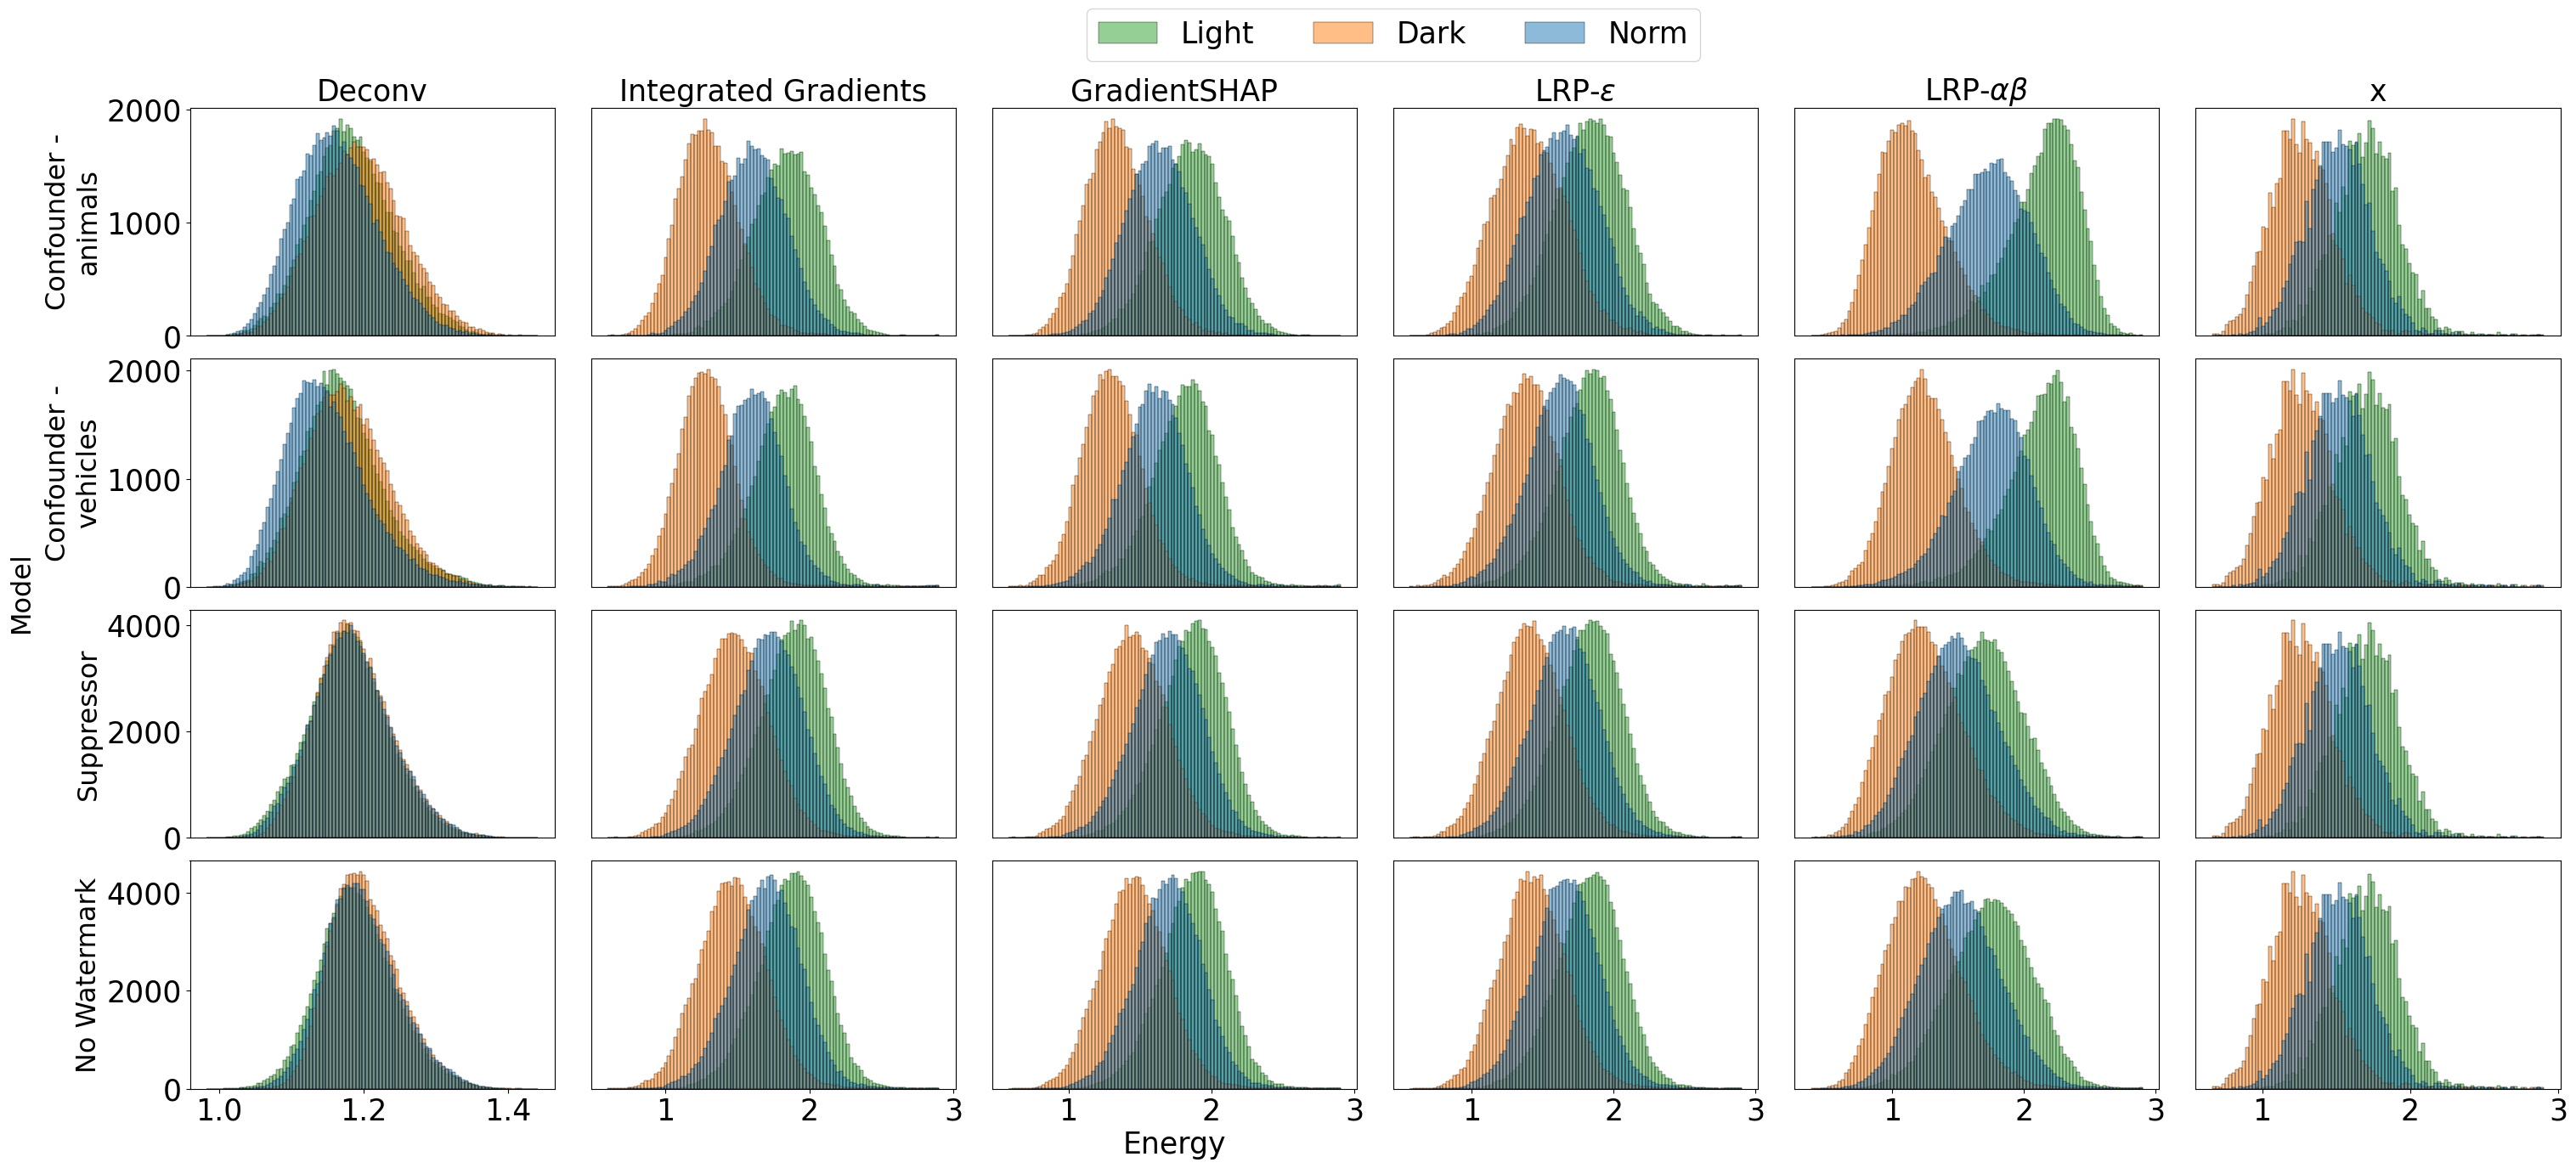

In [102]:
plot_coco_energies(conf_animals, conf_vehicles, sup, norm, x_norm, x_dark, x_light, rescaled=False)

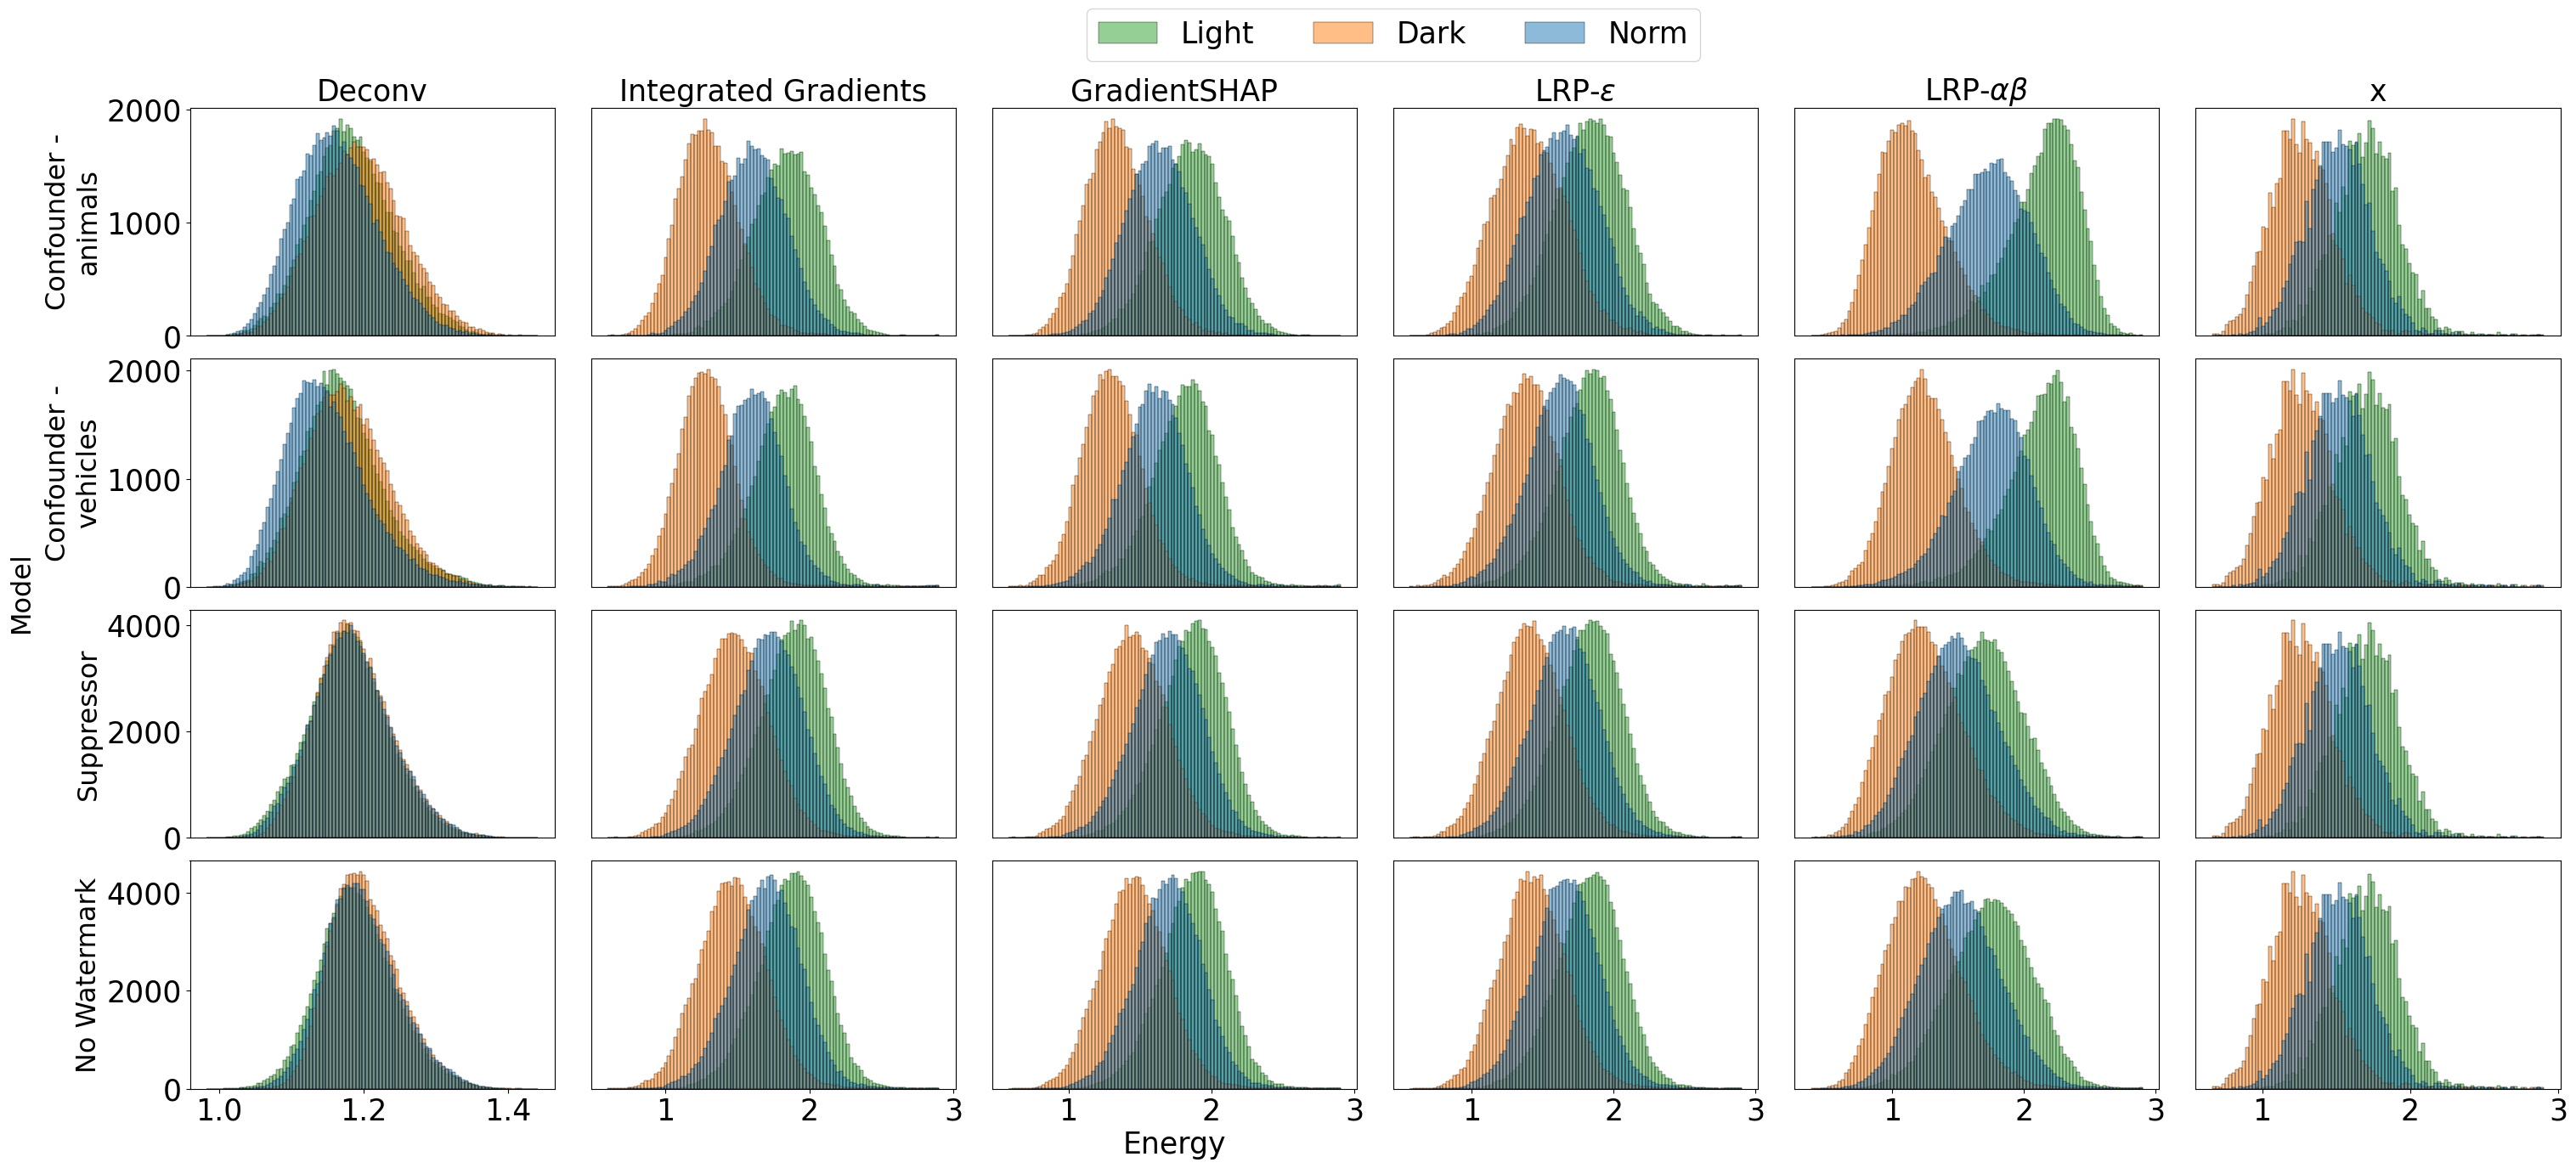

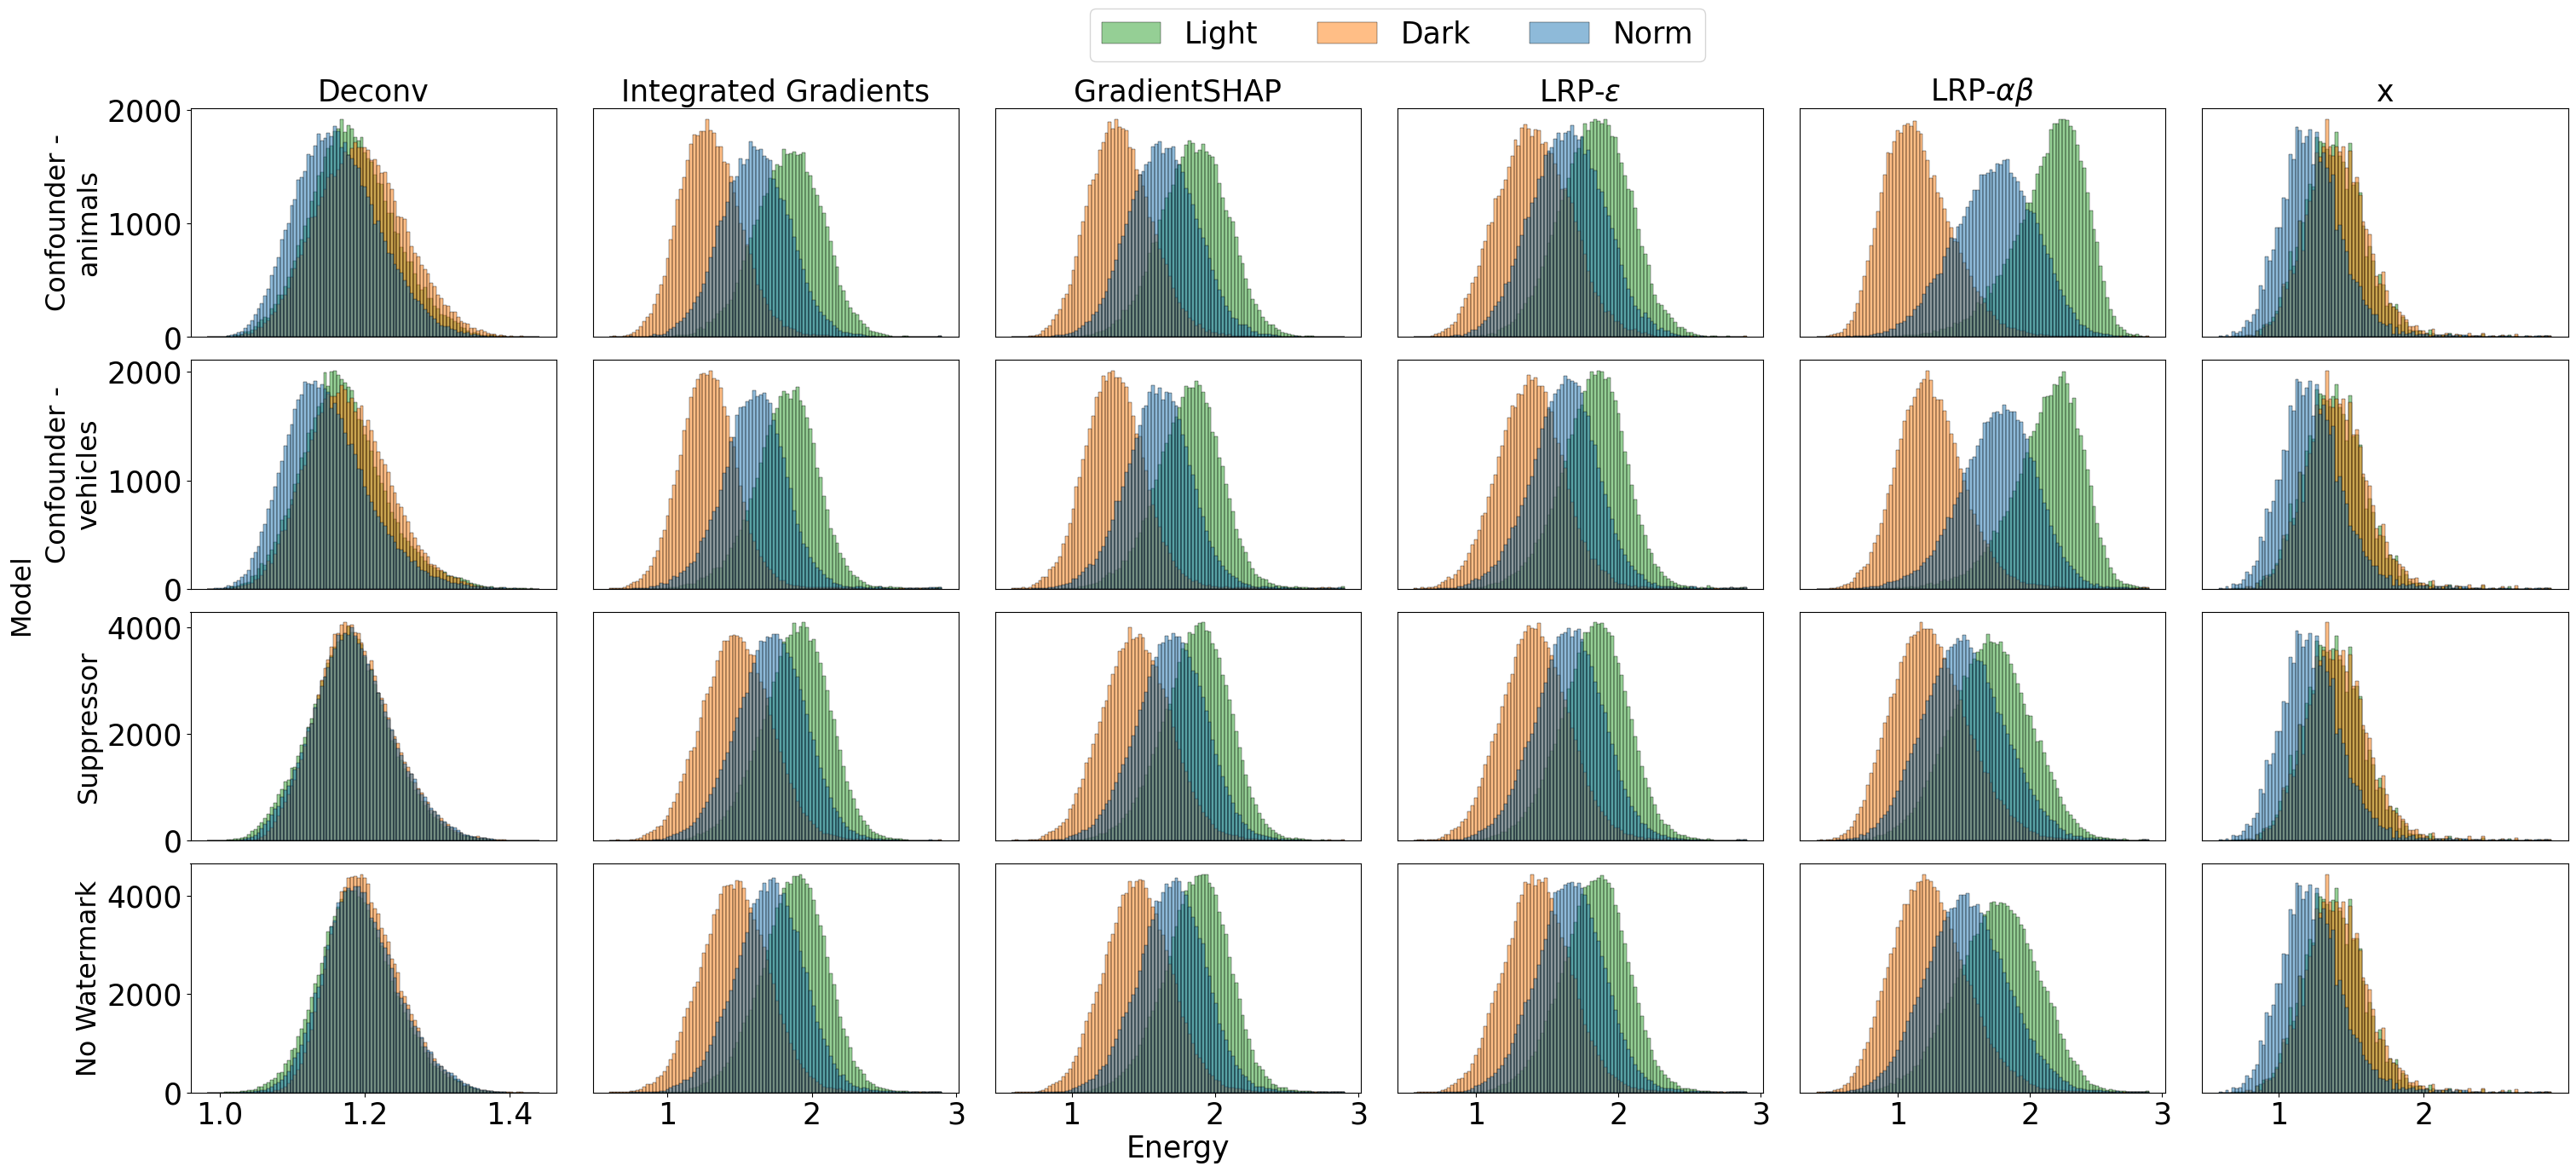

In [103]:
for rescaled in [False,True]:
    conf_animals, conf_vehicles, sup, norm = get_coco_energies(rescaled=rescaled)
    x_norm, x_dark, x_light = get_coco_xs(rescaled=rescaled)
    plot_coco_energies(conf_animals, conf_vehicles, sup, norm, x_norm, x_dark, x_light, rescaled=rescaled)

In [172]:
for n_method, method_name in enumerate(energies['conf']['conf'][1]):
    print(method_name.upper())
    print(f'====== CONF ======')
    
    print('model: norm ', round(np.mean(np.array(conf[n_method][0])),3))
    print('model: dark', round(np.mean(np.array(conf[n_method][1])),3))
    print('model: light', round(np.mean(np.array(conf[n_method][2])),3))

    print(f'\n====== SUP ======')
    
    print('model: norm ', round(np.mean(np.array(sup[n_method][0])),3))
    print('model: dark', round(np.mean(np.array(sup[n_method][1])),3))
    print('model: light', round(np.mean(np.array(sup[n_method][2])),3))
    
    print(f'\n====== NORM ======')
    
    print('model: norm ', round(np.mean(np.array(norm[n_method])),3))



DECONV
====== CONF ======
model: norm  1.186
model: dark 1.435
model: light 1.172

====== SUP ======
model: norm  1.156
model: dark 1.159
model: light 1.145

====== NORM ======
model: norm  1.186
INT_GRADS
====== CONF ======
model: norm  1.914
model: dark 1.668
model: light 2.079

====== SUP ======
model: norm  1.745
model: dark 1.477
model: light 1.929

====== NORM ======
model: norm  1.757
SHAP
====== CONF ======
model: norm  1.888
model: dark 1.646
model: light 2.05

====== SUP ======
model: norm  1.736
model: dark 1.468
model: light 1.923

====== NORM ======
model: norm  1.754
LRP
====== CONF ======
model: norm  1.669
model: dark 1.473
model: light 1.893

====== SUP ======
model: norm  1.708
model: dark 1.445
model: light 1.894

====== NORM ======
model: norm  1.718
LRP_AB
====== CONF ======
model: norm  1.695
model: dark 1.22
model: light 2.124

====== SUP ======
model: norm  1.537
model: dark 1.258
model: light 1.733

====== NORM ======
model: norm  1.581


In [185]:
split = 0
model_ind = 0 
rgb_string = ''
dataset = 'sup'

with open(f'./artifacts/split_{split}_coco_data_{dataset}_test.pkl', 'rb') as f:
    [data_sup, _, _, _, manips_sup] = pkl.load(f)

In [193]:
norm_inds = np.where(np.array(manips_sup) == 'norm')[0]
dark_inds = np.where(np.array(manips_sup) == 'dark')[0]
light_inds = np.where(np.array(manips_sup) == 'light')[0]

In [194]:
data_sup.shape[0]

4500

In [195]:
sum_norm = 0
sum_dark = 0
sum_light = 0

for x in data_sup:
    print(x.shape)
    break

(224, 224, 3)


In [205]:
print('avg norm sum: ', np.sum(np.abs(data_sup[norm_inds][:,:,:,1])) / data_sup[norm_inds].shape[0]) 
print('avg dark sum: ', np.sum(np.abs(data_sup[dark_inds][:,:,:,1])) / data_sup[dark_inds].shape[0])
print('avg light sum: ', np.sum(np.abs(data_sup[light_inds][:,:,:,1])) / data_sup[light_inds].shape[0])

avg norm sum:  25332.20082189045
avg dark sum:  17026.702487916216
avg light sum:  33615.636190626734
